# Non-reversible anchored Langevin — constant skew $J$ vs $J=0$

Companion to `anchored_langevin_laplace_1d.ipynb`. Same protocol throughout (N-particle ensemble from a
common start, $W_1$ to reference samples every iteration, terminal densities), now with a constant
skew-symmetric $J$ added to the anchored dynamics, compared against $J=0$.

## First: $J$ cannot exist in one dimension

A skew-symmetric matrix satisfies $J^\top=-J$, so its diagonal is zero. In $d=1$ that leaves
$J=(0)$ — **the only $1\times1$ skew-symmetric matrix is zero**. Non-reversibility of this type is not
merely ineffective for a univariate target, it is unavailable: any constant-$J$ scheme in $d=1$ *is* the
$J=0$ scheme. So "univariate Laplace + constant $J$" requires enlarging the state space. Two routes, both
run below:

* **Route 1 (Experiment 1–2).** Take the target to be a product of Laplace coordinates in $d=3$ with
  *different* scales $b=(0.5,1,2)$ — the same anisotropy as the Gaussian notebook's
  $\sigma=(0.25,1,4)$ — and use that notebook's constant skew matrix $J_a$ directly.
* **Route 2 (Experiment 3).** Keep the univariate Laplace as the object of interest and **lift** it: sample
  $\pi(x_1,x_2)\propto e^{-|x_1|/b_1}e^{-|x_2|/b_2}$ on $\mathbb{R}^2$ with a skew coupling, then read off
  the $x_1$-marginal, which is exactly the univariate Laplace. The auxiliary coordinate exists only to give
  $J$ something to rotate against.

## The non-reversible anchored dynamics

With anchor $U_0$, $\Delta=U-U_0$, and constant skew $J$:

$$dX_t \;=\; -\,(I+J)\,\nabla U_0(X_t)\,e^{\Delta(X_t)}\,dt \;+\; \sqrt{2}\,e^{\Delta(X_t)/2}\,dW_t .$$

**Invariance.** The stationary Fokker–Planck condition is that the flux
$\mathcal F = b\,p - \nabla(D\,p)$ be divergence-free. With $D=e^{\Delta}$, $p=\pi\propto e^{-U}$, and
$D\pi \propto e^{-U_0}$:

$$\mathcal F \;=\; -(I+J)\nabla U_0\,e^{\Delta}\pi \;-\; \nabla\bigl(e^{-U_0}\bigr)/Z
\;=\; \underbrace{-\nabla U_0 e^{-U_0}/Z - \nabla(e^{-U_0})/Z}_{=\;0}
\;-\; J\,\nabla U_0\,e^{-U_0}/Z \;=\; \tfrac1Z\,J\,\nabla\bigl(e^{-U_0}\bigr),$$

and for constant skew $J$,
$\nabla\cdot\bigl(J\nabla\varphi\bigr)=\sum_{ij}J_{ij}\partial_i\partial_j\varphi = 0$, because the Hessian
is symmetric and $J$ is antisymmetric. So $\nabla\cdot\mathcal F=0$ and $\pi$ is invariant **for every $a$** —
$J$ changes the rate of convergence, never the target. The density plots below are the empirical check.

**A consequence worth stating.** The non-reversible term is $-J\nabla U_0\,e^{\Delta}$: it enters through
the gradient of the **anchor**, not of $U$. With the zero anchor $U_0=0$ we get $\nabla U_0=0$, so
**$J$ has no effect whatsoever** — the zero-anchor sampler is pure state-dependent diffusion and cannot be
made non-reversible this way. The anchor is what gives $J$ something to act on, so it is excluded here.

Euler–Maruyama, in the row-vector convention of the Gaussian notebook
(`x - lr * grad @ (I+J).T`):

$$X_{k+1} = X_k - \eta\,\bigl[\nabla U_0(X_k)\,e^{\Delta(X_k)}\bigr](I+J)^\top + \sqrt{2\eta}\;e^{\Delta(X_k)/2}\,\xi_k .$$

In [1]:
%matplotlib inline
import numpy as np
import torch
torch.set_default_dtype(torch.float64)
torch.set_printoptions(precision=10)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, laplace, ks_2samp

In [2]:
# -----------------------------
# Settings (same protocol as the companion notebook)
# -----------------------------
N        = 5000
max_iter = 2000
eta      = 5e-3
mu       = 0.0
delta    = 0.1       # pseudo-Huber smoothing
clamp_delta = 10.0
x_start  = 0.5
SEED     = 1006

A_MAIN = 2.0         # the "constant J" strength used in the head-to-head comparison

In [3]:
# -----------------------------
# Constant skew matrix J_a -- exactly the Gaussian notebook's J_fun
#   J[i,i+1] = a, J[i+1,i] = -a
# -----------------------------
def J_fun(dim, a):
    return torch.diag(a * torch.ones(dim - 1), diagonal=1) + torch.diag(-a * torch.ones(dim - 1), diagonal=-1)

print("J_1 in dim 3 =\n", J_fun(3, 1.0))
print("\nskew check, J + J^T =\n", J_fun(3, 1.0) + J_fun(3, 1.0).T)
print("\nthe only 1x1 skew-symmetric matrix:\n", J_fun(1, 1.0), " -> J is identically 0 in dim 1")

J_1 in dim 3 =
 tensor([[ 0.,  1.,  0.],
        [-1.,  0.,  1.],
        [ 0., -1.,  0.]])

skew check, J + J^T =
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

the only 1x1 skew-symmetric matrix:
 tensor([[0.]])  -> J is identically 0 in dim 1


In [4]:
# -----------------------------
# Product Laplace potential  U(x) = sum_i |x_i - mu|/b_i, and the anchors
# b is a (dim,) tensor of per-coordinate scales
# -----------------------------
@torch.no_grad()
def U_laplace(x, b):
    return torch.sum(torch.abs(x - mu) / b, dim=1)

@torch.no_grad()
def grad_U_laplace(x, b):
    return torch.sign(x - mu) / b

@torch.no_grad()
def U0_huber(x, b):
    return torch.sum(torch.sqrt((x - mu) ** 2 + delta ** 2) / b, dim=1)

@torch.no_grad()
def grad_U0_huber(x, b):
    return (x - mu) / (b * torch.sqrt((x - mu) ** 2 + delta ** 2))

# -----------------------------
# Subgradient LMC with constant J:  x <- x - eta * gradU @ (I+J).T + sqrt(2 eta) xi
# -----------------------------
@torch.no_grad()
def lmc_step_J(x, eta, b, M):
    return x - eta * (grad_U_laplace(x, b) @ M) + np.sqrt(2 * eta) * torch.randn_like(x)

# -----------------------------
# Anchored Langevin with constant J
#   x <- x - eta * [gradU0 * exp(Delta)] @ (I+J).T + sqrt(2 eta) * exp(Delta/2) * xi
# grad U is never evaluated.
# -----------------------------
@torch.no_grad()
def anchored_step_J(x, eta, b, M, clamp=clamp_delta):
    Delta = U_laplace(x, b) - U0_huber(x, b)
    if clamp is not None:
        Delta = torch.clamp(Delta, -clamp, clamp)
    g = grad_U0_huber(x, b) * torch.exp(Delta).unsqueeze(1)
    return x - eta * (g @ M) + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x)

In [5]:
# -----------------------------
# Reference samples + the sampling floor (W1 a perfect sampler would attain
# against the same fixed reference sample, per coordinate)
# -----------------------------
def sample_target(b_list, size, rng):
    return np.stack([rng.laplace(mu, bi, size=size) for bi in b_list], axis=1)

def w1_floor(ref, b_list, size, rng, reps=20):
    return [float(np.mean([wasserstein_distance(ref[:, i], rng.laplace(mu, b_list[i], size))
                           for _ in range(reps)]))
            for i in range(len(b_list))]

In [6]:
# -----------------------------
# One chain: (sampler, a) on the product-Laplace target
# track_coords = which coordinates to record W1 for (None = all)
# -----------------------------
def run_chain(b_list, a, eta, sampler="anchored", max_iter=max_iter, N=N,
              ref=None, seed=SEED, track_coords=None, track=True):
    dim = len(b_list)
    torch.manual_seed(seed)
    b = torch.tensor(b_list)
    M = (torch.eye(dim) + J_fun(dim, a)).T
    step = anchored_step_J if sampler == "anchored" else lmc_step_J

    x = torch.full((N, dim), x_start)
    coords = track_coords if track_coords is not None else list(range(dim))
    W = []
    for _ in range(max_iter):
        x = step(x, eta, b, M)
        if track:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in coords])
    return x.numpy(), (np.array(W) if track else None)

## Experiment 1 — anisotropic product Laplace in $d=3$, $J_a$ vs $J=0$

Target $\pi(x)\propto\exp\bigl(-\sum_i |x_i|/b_i\bigr)$ on $\mathbb{R}^3$ with $b=(0.5,1,2)$.
Four chains: {subgradient LMC, anchored} $\times$ {$J=0$, $J_a$ with $a=2$}, all from the same start with
the same stepsize.

In [7]:
B3 = [0.5, 1.0, 2.0]

rng = np.random.default_rng(SEED)
ref3 = sample_target(B3, N, rng)
floor3 = w1_floor(ref3, B3, N, rng)
print("sampling floor per coordinate:", np.round(floor3, 4))

RUNS = {
    "Subgradient LMC (J = 0)":      ("lmc",      0.0),
    "Subgradient LMC (J_a, a = {})".format(A_MAIN): ("lmc",      A_MAIN),
    "Anchored (J = 0)":             ("anchored", 0.0),
    "Anchored (J_a, a = {})".format(A_MAIN):        ("anchored", A_MAIN),
}

exp1 = {}
for name, (sampler, a) in RUNS.items():
    xf, W = run_chain(B3, a, eta, sampler=sampler, ref=ref3)
    exp1[name] = {"x": xf, "W1": W}
    print("{:<34} final W1 = {}".format(name, np.round(W[-100:].mean(axis=0), 4)))

sampling floor per coordinate: [0.021  0.0415 0.1064]


Subgradient LMC (J = 0)            final W1 = [0.0218 0.0323 0.1914]


Subgradient LMC (J_a, a = 2.0)     final W1 = [0.0232 0.0351 0.1229]


Anchored (J = 0)                   final W1 = [0.022  0.0315 0.2116]


Anchored (J_a, a = 2.0)            final W1 = [0.0224 0.0339 0.1328]


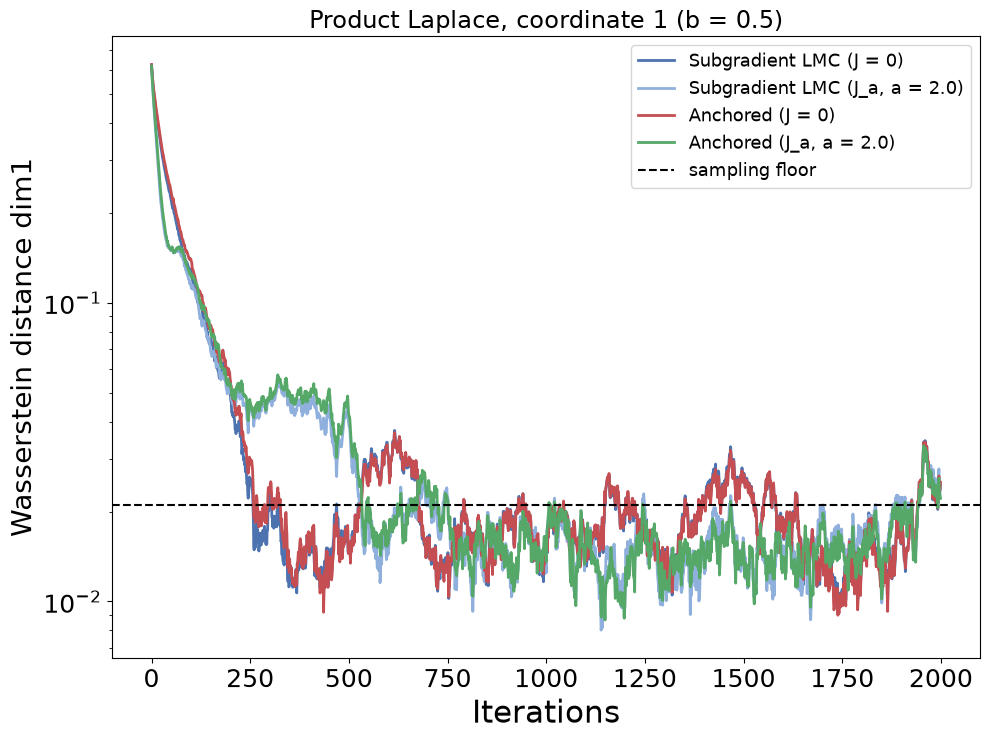

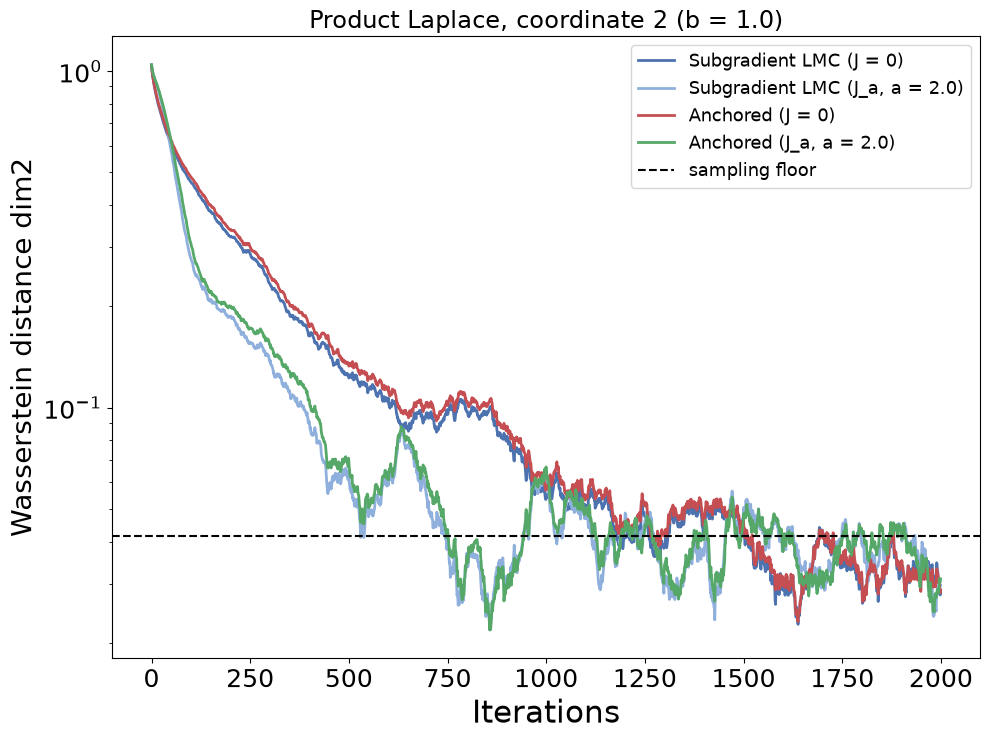

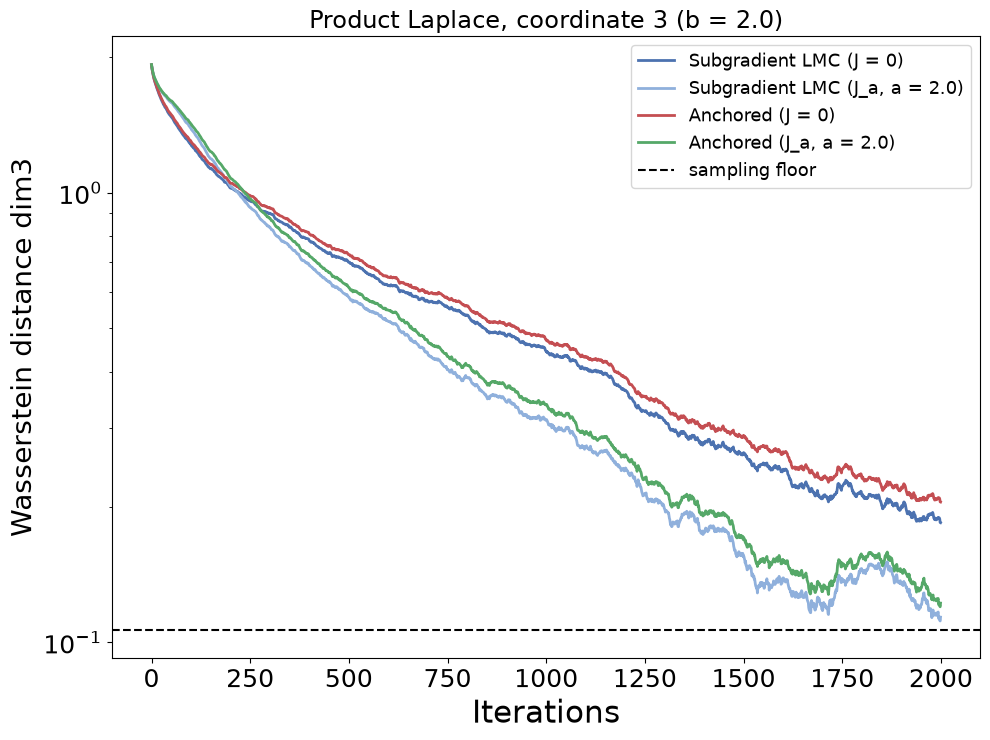

In [8]:
COLORS1 = {
    "Subgradient LMC (J = 0)":                      "#4C72B0",
    "Subgradient LMC (J_a, a = {})".format(A_MAIN): "#8FB0DC",
    "Anchored (J = 0)":                             "#C44E52",
    "Anchored (J_a, a = {})".format(A_MAIN):        "#55A868",
}

for i, bi in enumerate(B3):
    plt.figure(figsize=(10, 7.5))
    for name in RUNS:
        plt.plot(exp1[name]["W1"][:, i], linewidth=2, color=COLORS1[name], label=name)
    plt.axhline(floor3[i], color="k", linestyle="--", linewidth=1.5, label="sampling floor")
    plt.yscale("log")
    plt.xlabel("Iterations", fontsize=22)
    plt.ylabel("Wasserstein distance dim{}".format(i + 1), fontsize=20)
    plt.title("Product Laplace, coordinate {} (b = {})".format(i + 1, bi), fontsize=17)
    plt.tick_params(labelsize=18)
    plt.legend(loc="best", fontsize=13)
    plt.tight_layout()
    plt.savefig("figures/nonrev_w1_dim{}.pdf".format(i + 1), dpi=300, bbox_inches="tight")
    plt.show()

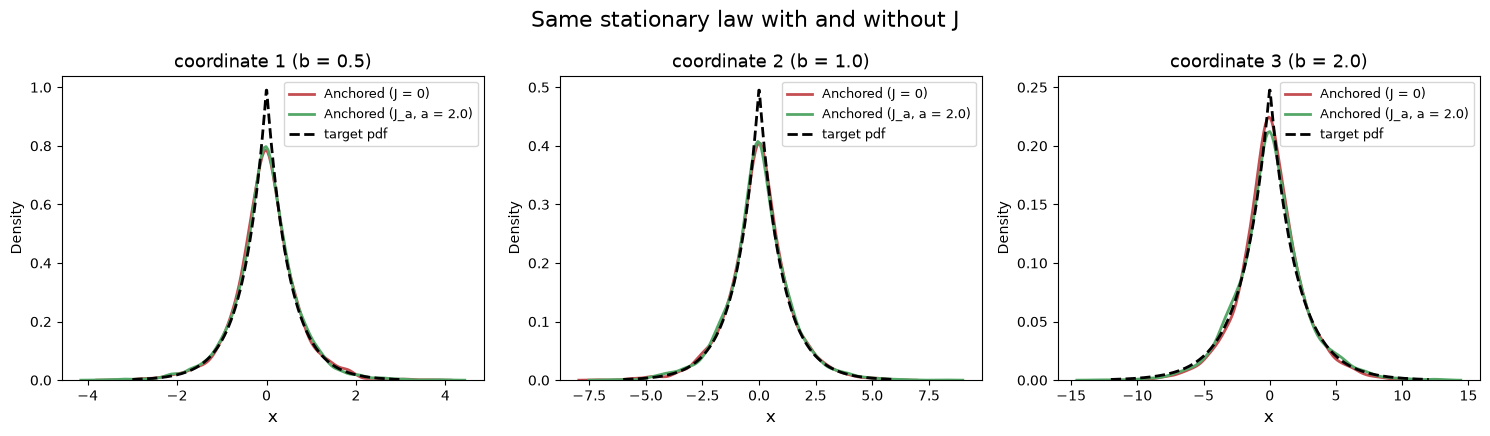

In [9]:
# Invariance check: J changes the rate, not the target.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for i, (ax, bi) in enumerate(zip(axes, B3)):
    grid = np.linspace(-6 * bi, 6 * bi, 600)
    for name in ["Anchored (J = 0)", "Anchored (J_a, a = {})".format(A_MAIN)]:
        sns.kdeplot(x=exp1[name]["x"][:, i], ax=ax, color=COLORS1[name], linewidth=2, label=name)
    ax.plot(grid, laplace.pdf(grid, loc=mu, scale=bi), "k--", linewidth=2, label="target pdf")
    ax.set_title("coordinate {} (b = {})".format(i + 1, bi), fontsize=13)
    ax.set_xlabel("x", fontsize=12)
    ax.legend(fontsize=9)
fig.suptitle("Same stationary law with and without J", fontsize=16)
plt.tight_layout()
plt.savefig("figures/nonrev_density_invariance.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# KS statistics against the reference sample -- both should be equally good
print("{:<40}{:>10}{:>10}{:>10}".format("method", "KS dim1", "KS dim2", "KS dim3"))
print("-" * 70)
for name in RUNS:
    ks = [ks_2samp(ref3[:, i], exp1[name]["x"][:, i]).statistic for i in range(3)]
    print("{:<40}".format(name) + "".join("{:>10.4f}".format(v) for v in ks))

method                                     KS dim1   KS dim2   KS dim3
----------------------------------------------------------------------
Subgradient LMC (J = 0)                     0.0246    0.0122    0.0256
Subgradient LMC (J_a, a = 2.0)              0.0192    0.0146    0.0190
Anchored (J = 0)                            0.0244    0.0118    0.0278
Anchored (J_a, a = 2.0)                     0.0174    0.0174    0.0224


## Experiment 2 — how much $J$, and what it costs

Sweep $a$ for the anchored sampler at fixed $\eta$. $J$ mixes the slow coordinate with the fast ones, so
the interesting question is whether the gain on coordinate 3 is paid for by the others.

In [11]:
A_SWEEP = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]

sweep = {}
for a in A_SWEEP:
    xf, W = run_chain(B3, a, eta, sampler="anchored", ref=ref3)
    sweep[a] = W[-100:].mean(axis=0)
    print("a = {:<5} final W1 = {}".format(a, np.round(sweep[a], 4)))

a = 0.0   final W1 = [0.022  0.0315 0.2116]


a = 0.5   final W1 = [0.0222 0.0304 0.1969]


a = 1.0   final W1 = [0.0208 0.0383 0.1486]


a = 2.0   final W1 = [0.0224 0.0339 0.1328]


a = 4.0   final W1 = [0.0273 0.0658 0.1382]


a = 8.0   final W1 = [0.0747 0.1864 0.1401]


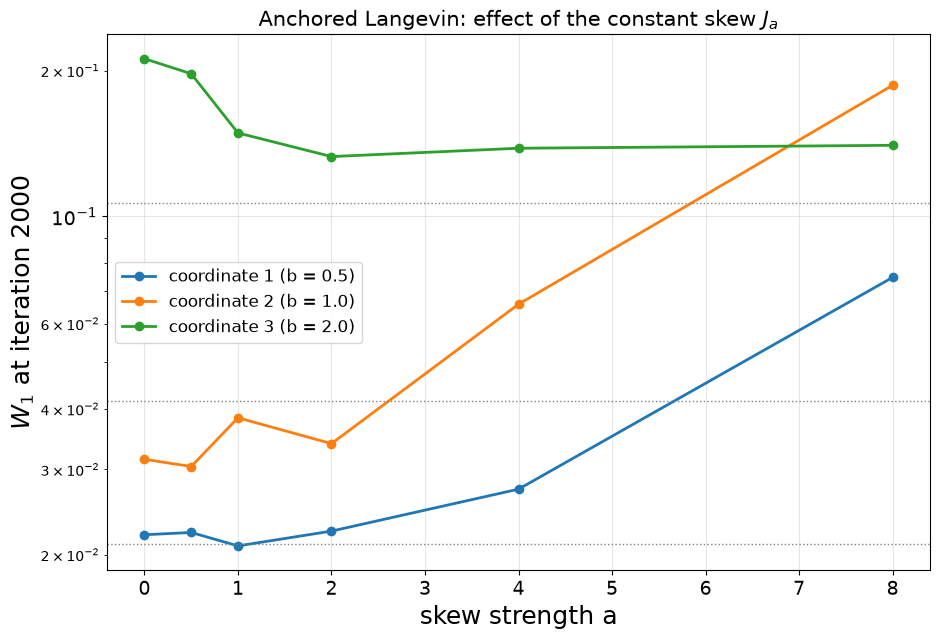

In [12]:
plt.figure(figsize=(9.5, 6.5))
for i, bi in enumerate(B3):
    plt.plot(A_SWEEP, [sweep[a][i] for a in A_SWEEP], marker="o", linewidth=2,
             label="coordinate {} (b = {})".format(i + 1, bi))
    plt.axhline(floor3[i], linestyle=":", linewidth=1, color="gray")
plt.yscale("log")
plt.xlabel("skew strength a", fontsize=18)
plt.ylabel("$W_1$ at iteration 2000", fontsize=18)
plt.title("Anchored Langevin: effect of the constant skew $J_a$", fontsize=15)
plt.tick_params(labelsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/nonrev_sweep_a.pdf", dpi=300, bbox_inches="tight")
plt.show()

The fast coordinates get *worse* at large $a$. That is a discretization artefact, not a property of the
diffusion: the non-reversible drift has magnitude $\propto a$, so Euler error grows with $a$ at fixed
$\eta$. Refining $\eta$ at fixed physical horizon $T=\eta\cdot n$ should recover them.

In [13]:
print("a = 8, fixed horizon T = eta * n_steps = 10")
print("{:<22}{:>10}{:>10}{:>10}".format("(eta, n_steps)", "dim1", "dim2", "dim3"))
print("-" * 55)
for eta_r, n_r in [(5e-3, 2000), (2.5e-3, 4000), (1e-3, 10000)]:
    xf, _ = run_chain(B3, 8.0, eta_r, sampler="anchored", max_iter=n_r, ref=ref3, track=False)
    w = [wasserstein_distance(ref3[:, i], xf[:, i]) for i in range(3)]
    print("{:<22}".format("({}, {})".format(eta_r, n_r)) + "".join("{:>10.4f}".format(v) for v in w))
print("\nsampling floor      " + "".join("{:>10.4f}".format(v) for v in floor3))

a = 8, fixed horizon T = eta * n_steps = 10
(eta, n_steps)              dim1      dim2      dim3
-------------------------------------------------------


(0.005, 2000)             0.0850    0.1750    0.1210


(0.0025, 4000)            0.0334    0.0757    0.1114


(0.001, 10000)            0.0248    0.0422    0.1250

sampling floor          0.0210    0.0415    0.1064


## Experiment 3 — back to the univariate Laplace, via a 2D lift

Route 2. The target of interest is the univariate $\pi_1(x_1)\propto e^{-|x_1|/b_1}$ with $b_1=2$ (the
slowest-mixing scale from the companion notebook). We sample the product
$\pi(x_1,x_2)\propto e^{-|x_1|/b_1}e^{-|x_2|/b_2}$ on $\mathbb{R}^2$ with $b_2=0.5$ and the $2\times2$ skew
matrix $J_a=\begin{pmatrix}0&a\\-a&0\end{pmatrix}$, and record $W_1$ **for the $x_1$-marginal only**.

At $a=0$ the two coordinates decouple, so the $a=0$ curve *is* the univariate anchored chain of the
companion notebook — an exact like-for-like baseline.

In [14]:
B2 = [2.0, 0.5]     # x1 = univariate Laplace of interest, x2 = auxiliary
A_LIFT = [0.0, 1.0, 2.0, 4.0, 8.0]

rng2 = np.random.default_rng(SEED)
ref2 = sample_target(B2, N, rng2)
floor2 = w1_floor(ref2, B2, N, rng2)[0]
print("sampling floor for the x1 marginal:", round(floor2, 4))

lift = {}
for a in A_LIFT:
    xf, W = run_chain(B2, a, eta, sampler="anchored", ref=ref2, track_coords=[0])
    lift[a] = {"x": xf, "W1": W[:, 0]}
    print("a = {:<5} final W1 (x1 marginal) = {:.4f}".format(a, W[-100:, 0].mean()))

sampling floor for the x1 marginal: 0.0875


a = 0.0   final W1 (x1 marginal) = 0.2722


a = 1.0   final W1 (x1 marginal) = 0.0983


a = 2.0   final W1 (x1 marginal) = 0.0713


a = 4.0   final W1 (x1 marginal) = 0.0813


a = 8.0   final W1 (x1 marginal) = 0.1245


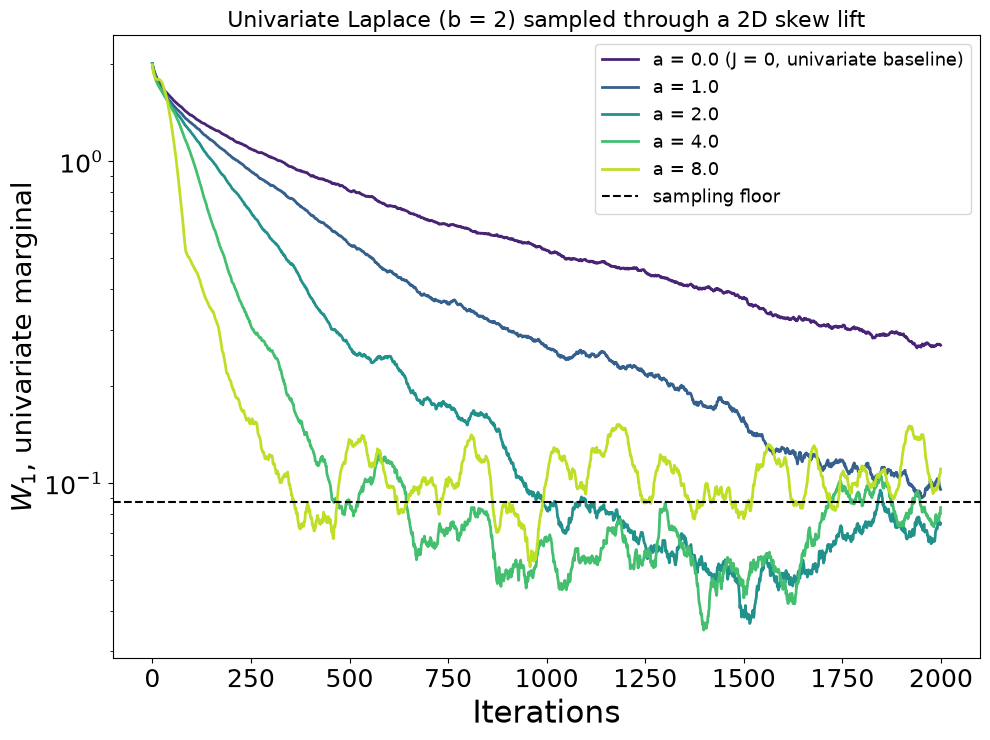

In [15]:
plt.figure(figsize=(10, 7.5))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(A_LIFT)))
for c, a in zip(cmap, A_LIFT):
    lab = "a = {} (J = 0, univariate baseline)".format(a) if a == 0 else "a = {}".format(a)
    plt.plot(lift[a]["W1"], linewidth=2, color=c, label=lab)
plt.axhline(floor2, color="k", linestyle="--", linewidth=1.5, label="sampling floor")
plt.yscale("log")
plt.xlabel("Iterations", fontsize=22)
plt.ylabel("$W_1$, univariate marginal", fontsize=20)
plt.title("Univariate Laplace (b = 2) sampled through a 2D skew lift", fontsize=16)
plt.tick_params(labelsize=18)
plt.legend(loc="best", fontsize=13)
plt.tight_layout()
plt.savefig("figures/nonrev_lift_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

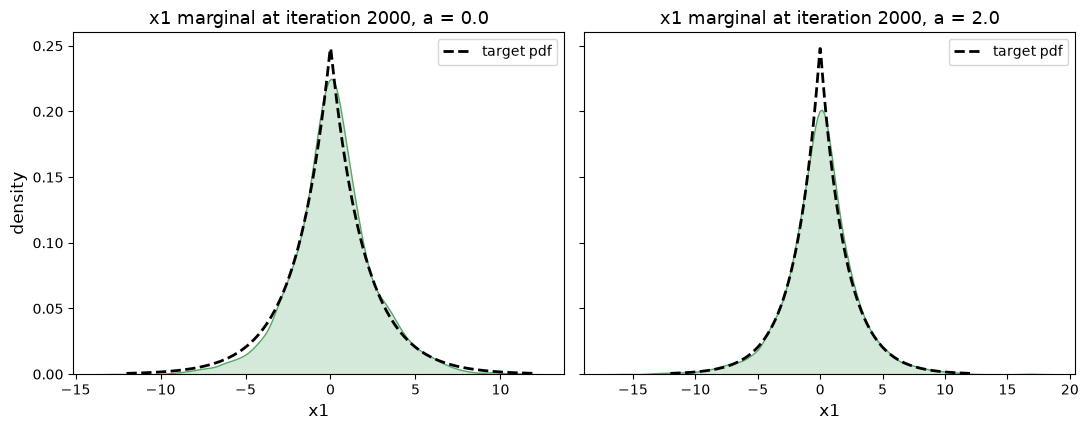

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
grid = np.linspace(-12, 12, 700)
for ax, a in zip(axes, [0.0, 2.0]):
    sns.kdeplot(x=lift[a]["x"][:, 0], fill=True, ax=ax, color="#55A868")
    ax.plot(grid, laplace.pdf(grid, loc=mu, scale=B2[0]), "k--", linewidth=2, label="target pdf")
    ax.set_title("x1 marginal at iteration 2000, a = {}".format(a), fontsize=13)
    ax.set_xlabel("x1", fontsize=12)
    ax.legend(fontsize=10)
axes[0].set_ylabel("density", fontsize=12)
plt.tight_layout()
plt.savefig("figures/nonrev_lift_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**$J$ does not exist in one dimension.** $J^\top=-J$ forces $J=0$ when $d=1$, so a constant-$J$ scheme
applied to a univariate target is literally the $J=0$ scheme. Everything below therefore either widens the
target to $d=3$ or lifts the univariate one to $d=2$.

**$J$ acts through the anchor.** The non-reversible drift is $-J\nabla U_0 e^{\Delta}$, so with the zero
anchor ($\nabla U_0=0$) the value of $a$ is irrelevant — that sampler cannot be made non-reversible this
way. All runs here use the pseudo-Huber anchor.

**Invariance is unaffected, as derived.** Across $a\in[0,8]$ the terminal densities lie on the target and
the KS statistics are comparable; $\nabla\cdot(J\nabla\varphi)=0$ for constant skew $J$ means the target is
untouched and only the rate changes.

**Constant $J$ accelerates the slow coordinate.** In $d=3$ with $b=(0.5,1,2)$, coordinate 3 is the
bottleneck — the only one that has not converged by iteration 2000. Anchored $W_1$ there falls from
$0.212$ at $a=0$ to $0.133$ at $a=2$, a $1.6\times$ improvement, with the curves separating within a few
hundred iterations. The subgradient baseline responds almost identically ($0.191\to0.123$), so the
acceleration is the skew term's doing, not the anchoring's — the two are independent knobs and they
compose.

**The cost is discretization error, and it is controllable.** At fixed $\eta$ the already-converged fast
coordinates degrade as $a$ grows ($a=8$: dim1 $0.022\to0.075$, dim2 $0.032\to0.186$), because the drift
magnitude scales with $a$. Refining $\eta$ at fixed horizon recovers most of it ($\eta=10^{-3}$ at $a=8$:
dim1 $0.025$, dim2 $0.042$), confirming discretization rather than the diffusion is at fault. So $a$ and
$\eta$ move in opposite directions, and the sweep has an interior optimum: at $\eta=5\times10^{-3}$,
$a=2$ was best for coordinate 3 ($0.133$, against $0.149$ at $a=1$ and $0.138$ at $a=4$), and the gain
flattens out well before the fast coordinates start to suffer.

**The lift makes $J$ available to a genuinely univariate target.** Sampling
$\pi(x_1)\pi(x_2)$ on $\mathbb{R}^2$ with $b_1=2$, $b_2=0.5$ and reading off the $x_1$-marginal, $W_1$ at
iteration 2000 drops from $0.272$ at $a=0$ to $0.071$ at $a=2$ — a $3.8\times$ improvement on the
univariate quantity of interest, for the cost of one extra scalar per particle. At $a=2$ the marginal is
below its sampling floor of $0.088$, i.e. converged, while the $a=0$ chain is still a factor of 3 away.
The optimum is interior here too ($a=8$ gives $0.125$), and $a=0$ reproduces the univariate chain of the
companion notebook exactly, since the coordinates decouple when $J=0$.